# TODO:
* [x] move lattice code to class
* [x] add determination of specializer/generalizer; check implementation of specializer
* [ ] improve projection
* [ ] use KNN graph or graph from umap
* [x] Set color to scenario ID
* [x] Compute number of generalizers needed so that at least k specailizers exist per feature
* [x] Function to determine best specialization
* [ ] Weighted sum instead of minimax for generalizers; may be z-score normalize before weighted sum?; maybe show weighed sum as percentile?
* [x] use z-score or rank in PCP

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from importlib import reload 

In [2]:
import os

USER_PATH = '~/OneDrive - PNNL'
DATA_PATH = 'E-COMP - mocodo'

path = os.path.join(os.path.expanduser(USER_PATH), DATA_PATH)


os.listdir(path)

['scenarios_wrevenues.csv',
 'scenarios_wrevenues_subset.csv',
 'design_solutions.csv',
 'design_solutions_v0.csv',
 'scenarios.csv',
 'MoCoDo formulation.docx',
 'design_solutions_per_scenario.csv']

# EDA Alternatives / Baselines

In [3]:
df_design = pd.read_csv(os.path.join(path, 'design_solutions_v0.csv'), index_col=0)

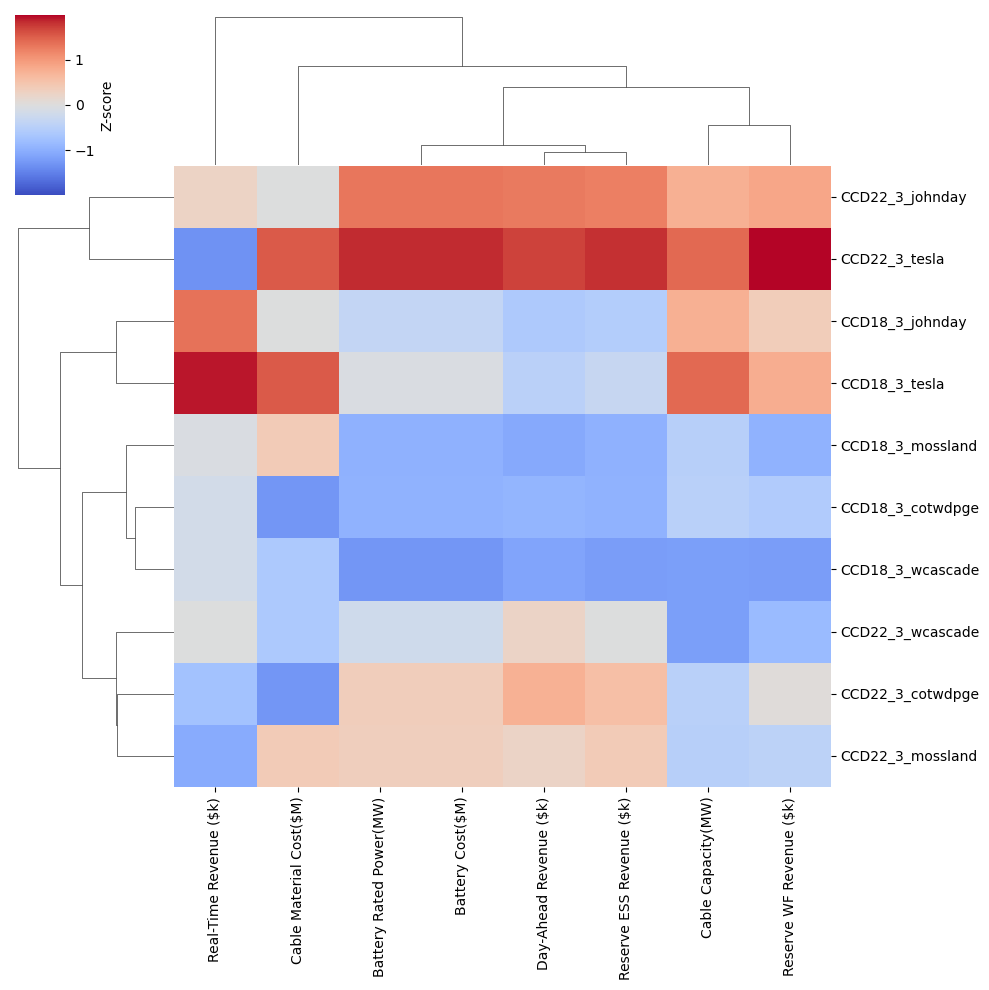

In [4]:
import seaborn as sns

df = df_design

X = (df - df.mean())/df.std()
vmax = vmax = X.abs().max().max()
vmin = -vmax
sns.clustermap(X, vmin=vmin, vmax=vmax, cmap='coolwarm', cbar_kws=dict(label='Z-score'))

# import matplotlib
# matplotlib.figure.Figure.colorbar.

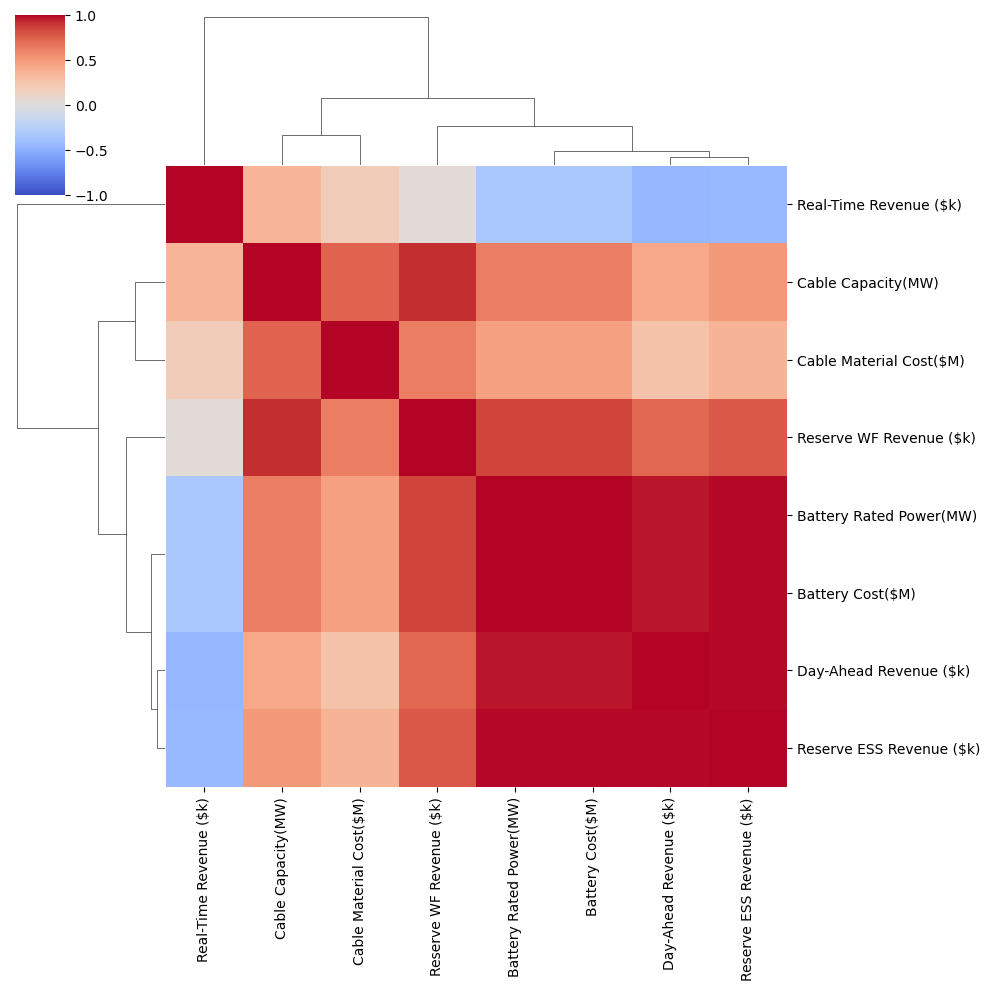

In [5]:
C = df.corr()
vmax = C.abs().max().max()
sns.clustermap(C, vmin=-vmax, vmax=vmax, cmap='coolwarm')

/Users/aren438/anaconda3/envs/moods/lib/python3.11/site-packages/umap/umap_.py:2433: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


(-9.209119248390198, -6.725126338005066, 1.9309396266937255, 4.432254838943481)

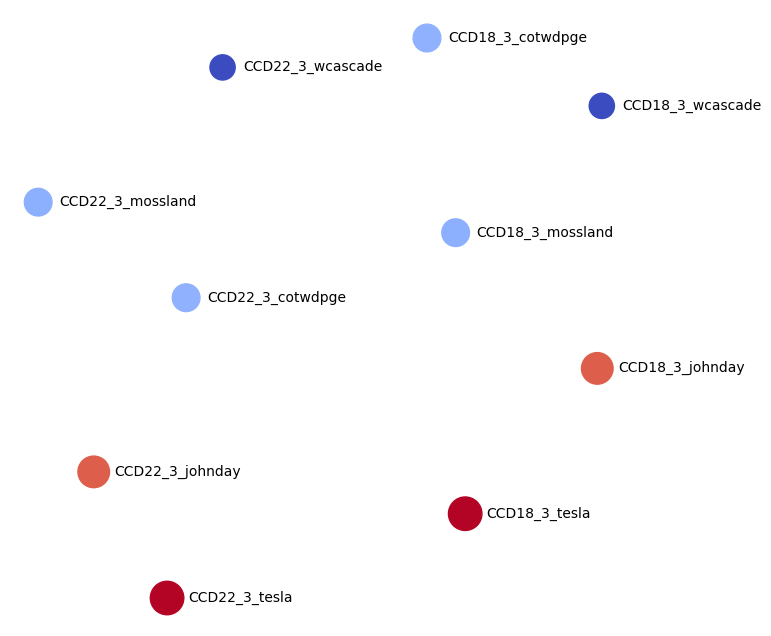

In [8]:
from umap import UMAP

by = df.columns[0]

plt.figure(figsize=(8, 8))

cmap = plt.cm.coolwarm
norm = plt.Normalize(-vmax, vmax)

pos = UMAP().fit_transform(X)
plt.scatter(*pos.T, s=df[by]/5, c=cmap(norm(X[by])))

for s, xy in zip(df.index, pos):
    plt.annotate(s, xy, va='center', xytext=(15, 0), textcoords='offset points')

plt.axis('off')


Cable Material Cost($M):  less --> more


<Figure size 800x800 with 0 Axes>

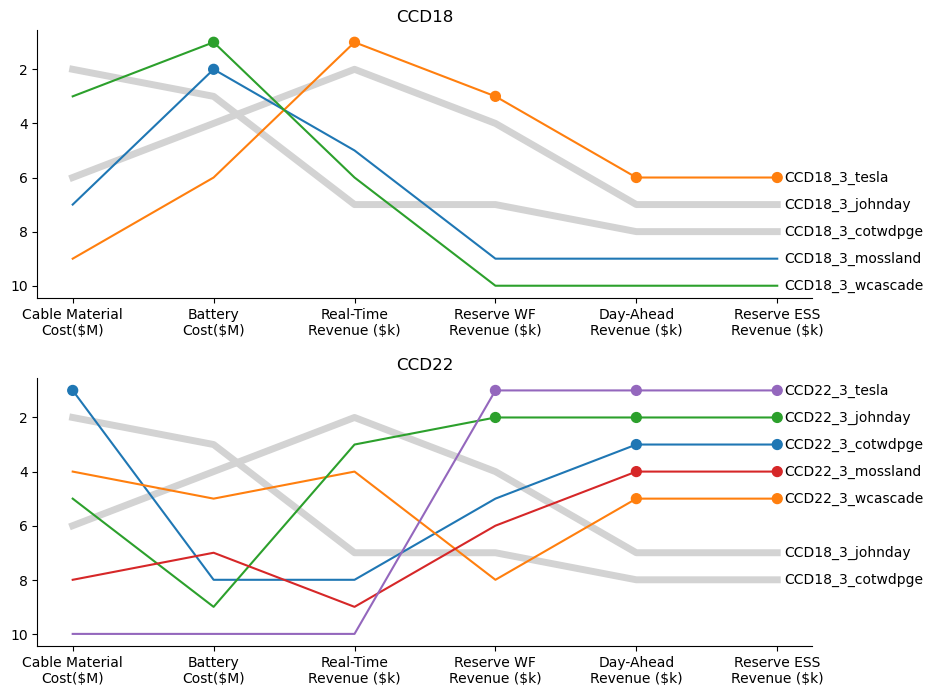

In [9]:
import tradeoff_lattice as tl; reload(tl)

df_design = pd.read_csv(os.path.join(path, 'design_solutions_v0.csv'), index_col=0)

ovars = [
    c
    for c in df_design.columns
    if '$' in c
]

def ovar_format(s):
    sep = ' Revenue'
    if ' Cost' in s:
        sep = ' Cost'

    left, right = s.split(sep)
    return f'{left}\n{sep[1:]}{right}'
    
ascending = [
    c
    for c in ovars
    if 'Cost' in c
]

dvars = set(df_design.columns).difference(ovars)

self = tl.DirectTradeoffLattice(
    df_design, ovars, dvars,
    ascending=ascending,
    # max_specializers=2,
    min_specializers=1,
    # n_generalizers=1,
)

by = ovars[0]

# plt.figure(figsize=(8, 8))
# plt.axis('off')
# self.draw(
#     by=by,
#     node_size=500,
#     with_edge_labels=self.dvars,
#     edge_labels_kwargs=dict(font_size=6, rotate=False),
#     node_labels_kwargs=dict(fontsize=8, fontweight='bold'),
#     show_negative=True,
#     show_positive=False,
# )

# plt.title(f'{by}:  less --> more')
print(f'{by}:  less --> more')
plt.savefig('design_solutions_tradeoffs_v0.pdf', format='pdf', bbox_inches='tight')

plt.figure(figsize=(10, 8))
self.plot_ovars_parallel_coords(
    x_label_format=ovar_format,
    use_rank=True,
    include_all_generalizers=True,
    facets = [
        i.split('_')[0]
        for i in self.rank.index
    ]
)

plt.subplots_adjust(hspace=.3)
# self.ovars_formatted()

# Larger Example

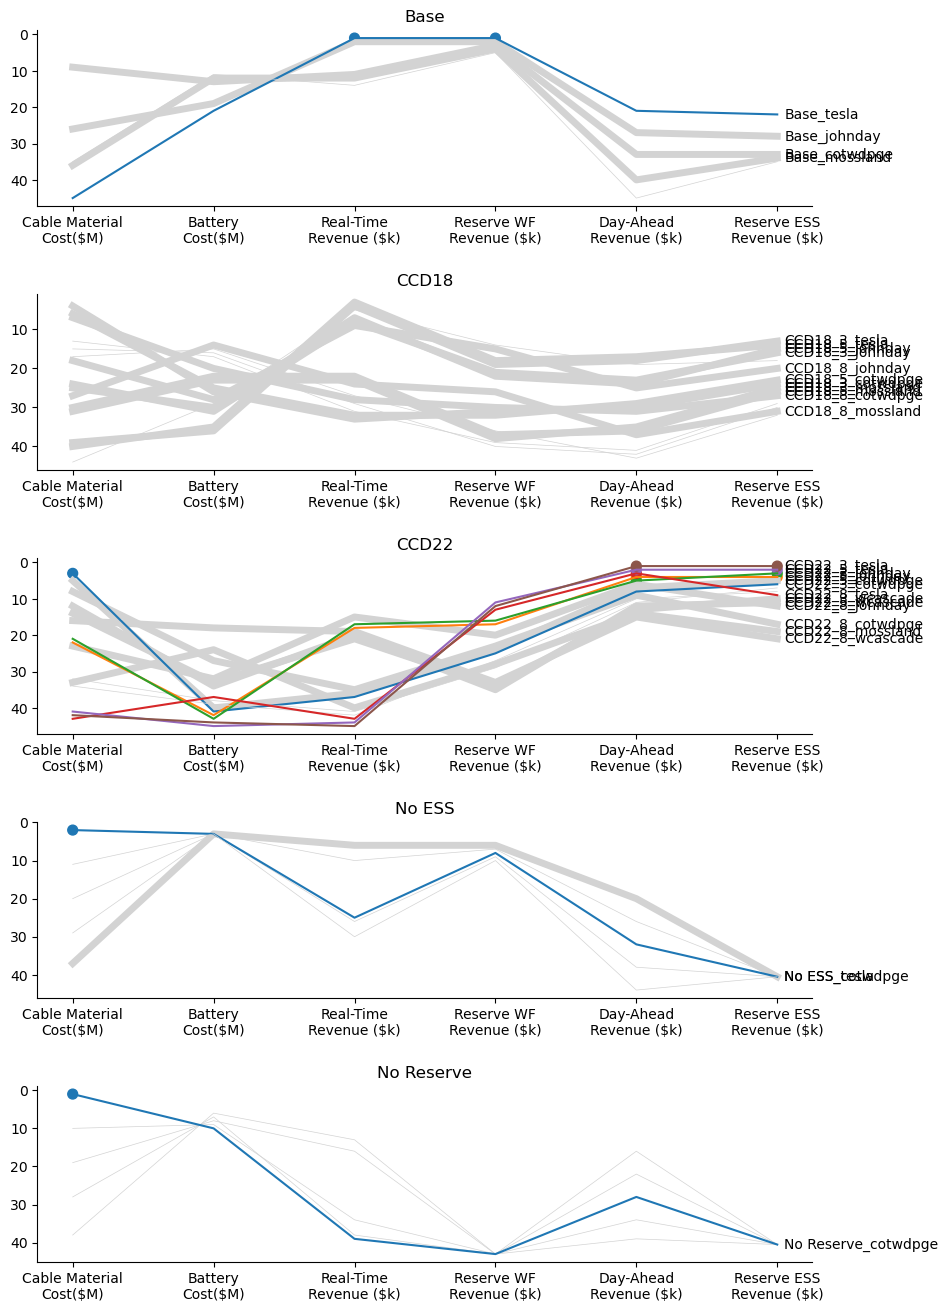

In [10]:
import tradeoff_lattice as tl; reload(tl)

df_design = pd.read_csv(os.path.join(path, 'design_solutions.csv'), index_col=0)

def get_cluster_name(s):
    parts = s.split('_')
    return '_'.join([parts[0], parts[-1]])
    
ovars = [
    c
    for c in df_design.columns
    if '$' in c
]

ascending = [
    c
    for c in ovars
    if 'Cost' in c
]

dvars = set(df_design.columns).difference(ovars)

self = tl.DirectTradeoffLattice(
    df_design,
    ovars, dvars,
    ascending=ascending,
    max_specializers=5,
    # min_specializers=1,
    # n_generalizers=10,
)

by = ovars[0]

# plt.figure(figsize=(12, 24))
# plt.axis('off')
# plt.title(f'{by}:  less --> more')
# self.draw(
#     by=by,
#     node_size=500,
#     with_edge_labels=self.dvars,
#     edge_labels_kwargs=dict(font_size=6, rotate=False),
#     node_labels_kwargs=dict(fontsize=8, fontweight='bold')
# )

# plt.savefig('design_solutions_tradeoffs.pdf', format='pdf', bbox_inches='tight')

plt.figure(figsize=(10, 16))
self.plot_ovars_parallel_coords(
    x_label_format=ovar_format,
    use_rank=True,
    facets = [
        i.split('_')[0]
        for i in self.rank.index
    ]
)

plt.subplots_adjust(hspace=.5)